# Chapter 18 — General N-Gram Models

Chapter 13 used one previous token, and Chapter 17 used two previous tokens.

This chapter generalizes both models by making the context length a parameter.

By the end of this chapter, you should be able to:

- relate n-gram size to context length;
- count targets after context tuples of any fixed length;
- train bigram, trigram, 5-gram, and 9-gram models with one implementation;
- compare unique contexts and average examples per context;
- measure unseen validation contexts;
- compute average validation negative log loss; and
- explain why longer exact context is not automatically better.

This chapter remains within count-based character language modeling.


## N-Gram Size and Context Length

An **n-gram** is a sequence of $n$ adjacent tokens.

For next-token prediction, the first $n-1$ tokens form the context and the final token is the target.

It is often clearer to name a model by its context length $C$, where $n=C+1$.

- Context length 1 produces a bigram model.

- Context length 2 produces a trigram model.

- Context length 4 produces a 5-gram model.

- Context length 8 produces a 9-gram model.


## The Exact-Context Tradeoff

Longer context can make a prediction more specific because `"the "` contains more information than `"e"`.

Exact longer contexts also repeat less often, so each probability estimate can receive less evidence.

With vocabulary size $V$ and context length $C$, there are up to $V^C$ possible exact contexts.

This rapid growth creates **sparsity**, meaning that many possible contexts are rare or absent from training.


## Use a Larger Repeated Fixture

The local corpus contains repeated sentence patterns so several context lengths can be compared meaningfully.

It is still a teaching fixture rather than a realistic training corpus.


In [1]:
corpus_lines = [
    "the cat sat on the mat.",
    "the cat sat on the rug.",
    "the cat slept on the mat.",
    "the dog sat on the mat.",
    "the dog ran in the yard.",
    "the dog slept on the rug.",
    "the bird sat in the tree.",
    "the bird sang in the tree.",
    "the child sat on the rug.",
    "the child ran in the yard.",
    "the cat ran in the yard.",
    "the dog ate the food.",
    "the cat ate the food.",
    "the bird ate the seed.",
    "the child ate the food.",
    "the cat looked at the dog.",
    "the small cat sat on the mat.",
    "the small dog ran in the yard.",
    "the small bird sang in the tree.",
    "the happy child sat on the rug.",
    "the happy dog slept on the mat.",
    "the dog looked at the cat.",
    "the bird looked at the child.",
    "the child looked at the bird.",
]

corpus_text = "\n".join(corpus_lines)

print(corpus_text)
print()
print("Line count:", len(corpus_lines))
print("Character count:", len(corpus_text))

the cat sat on the mat.
the cat sat on the rug.
the cat slept on the mat.
the dog sat on the mat.
the dog ran in the yard.
the dog slept on the rug.
the bird sat in the tree.
the bird sang in the tree.
the child sat on the rug.
the child ran in the yard.
the cat ran in the yard.
the dog ate the food.
the cat ate the food.
the bird ate the seed.
the child ate the food.
the cat looked at the dog.
the small cat sat on the mat.
the small dog ran in the yard.
the small bird sang in the tree.
the happy child sat on the rug.
the happy dog slept on the mat.
the dog looked at the cat.
the bird looked at the child.
the child looked at the bird.

Line count: 24
Character count: 642


## Split Training and Validation Text

The first sixteen lines fit the counts, while the final eight lines remain held out for evaluation.

Validation text must not contribute to the fitted context counts.


In [2]:
training_lines = corpus_lines[:16]
validation_lines = corpus_lines[16:]
training_text = "\n".join(training_lines)
validation_text = "\n".join(validation_lines)

print("Training lines:", len(training_lines))
print("Validation lines:", len(validation_lines))
print("Training characters:", len(training_text))
print("Validation characters:", len(validation_text))
print()
print("Validation text:")
print(validation_text)

Training lines: 16
Validation lines: 8
Training characters: 397
Validation characters: 244

Validation text:
the small cat sat on the mat.
the small dog ran in the yard.
the small bird sang in the tree.
the happy child sat on the rug.
the happy dog slept on the mat.
the dog looked at the cat.
the bird looked at the child.
the child looked at the bird.


## Build the Tokenizer From Training Text

The validation split must use only characters known by the training vocabulary.


In [3]:
def build_character_mappings(
    text: str,
) -> tuple[list[str], dict[str, int], dict[int, str]]:
    vocabulary = sorted(set(text))
    character_to_id = {
        character: character_id for character_id, character in enumerate(vocabulary)
    }
    id_to_character = {
        character_id: character for character, character_id in character_to_id.items()
    }
    return vocabulary, character_to_id, id_to_character


character_vocabulary, character_to_id, id_to_character = build_character_mappings(
    training_text
)
unknown_validation_characters = set(validation_text) - set(character_vocabulary)

print("Vocabulary size:", len(character_vocabulary))
print("Vocabulary:", [repr(character) for character in character_vocabulary])
print("Unknown validation characters:", unknown_validation_characters)
assert not unknown_validation_characters

Vocabulary size: 23
Vocabulary: ["'\\n'", "' '", "'.'", "'a'", "'b'", "'c'", "'d'", "'e'", "'f'", "'g'", "'h'", "'i'", "'k'", "'l'", "'m'", "'n'", "'o'", "'p'", "'r'", "'s'", "'t'", "'u'", "'y'"]
Unknown validation characters: set()


## Encode Both Splits

Exact round trips confirm that the shared tokenizer preserves both strings.


In [4]:
def encode_characters(
    text: str,
    character_to_id: dict[str, int],
) -> list[int]:
    token_ids = []
    for position, character in enumerate(text):
        if character not in character_to_id:
            raise ValueError(f"Unknown character {character!r} at position {position}.")
        token_ids.append(character_to_id[character])
    return token_ids


def decode_character_ids(
    token_ids: list[int],
    id_to_character: dict[int, str],
) -> str:
    characters = []
    for position, token_id in enumerate(token_ids):
        if token_id not in id_to_character:
            raise ValueError(f"Unknown token ID {token_id} at position {position}.")
        characters.append(id_to_character[token_id])
    return "".join(characters)


training_token_ids = encode_characters(training_text, character_to_id)
validation_token_ids = encode_characters(validation_text, character_to_id)

assert decode_character_ids(training_token_ids, id_to_character) == training_text
assert decode_character_ids(validation_token_ids, id_to_character) == validation_text
print("Training tokens:", len(training_token_ids))
print("Validation tokens:", len(validation_token_ids))

Training tokens: 397
Validation tokens: 244


## Inspect Generic Sliding Windows

The context-target pattern stays the same while only the context width changes.


In [5]:
def print_context_windows(
    text: str,
    context_length: int,
    number_of_windows: int,
) -> None:
    if context_length < 1:
        raise ValueError("context_length must be at least 1.")
    if number_of_windows < 0:
        raise ValueError("number_of_windows cannot be negative.")

    window_count = min(number_of_windows, max(0, len(text) - context_length))
    for start_position in range(window_count):
        context_text = text[start_position : start_position + context_length]
        target = text[start_position + context_length]
        print(
            f"window {start_position:>2}: context {context_text!r} → target {target!r}"
        )


for context_length in [1, 2, 4]:
    print("Context length:", context_length)
    print_context_windows(training_text, context_length, number_of_windows=5)
    print()

Context length: 1
window  0: context 't' → target 'h'
window  1: context 'h' → target 'e'
window  2: context 'e' → target ' '
window  3: context ' ' → target 'c'
window  4: context 'c' → target 'a'

Context length: 2
window  0: context 'th' → target 'e'
window  1: context 'he' → target ' '
window  2: context 'e ' → target 'c'
window  3: context ' c' → target 'a'
window  4: context 'ca' → target 't'

Context length: 4
window  0: context 'the ' → target 'c'
window  1: context 'he c' → target 'a'
window  2: context 'e ca' → target 't'
window  3: context ' cat' → target ' '
window  4: context 'cat ' → target 's'



## Count Targets for Any Context Length

The tuple type `tuple[int, ...]` permits any positive number of ordered token IDs.

The resulting `context_to_target_counts` structure generalizes the earlier bigram and trigram dictionaries.


In [6]:
from collections import Counter  # noqa: I001


Context = tuple[int, ...]


def build_context_counts(
    token_ids: list[int],
    context_length: int,
) -> dict[Context, Counter[int]]:
    if context_length < 1:
        raise ValueError("context_length must be at least 1.")
    if context_length >= len(token_ids):
        raise ValueError("context_length must be smaller than the token sequence.")

    context_to_target_counts: dict[Context, Counter[int]] = {}
    for start_position in range(len(token_ids) - context_length):
        context = tuple(token_ids[start_position : start_position + context_length])
        target_id = token_ids[start_position + context_length]
        if context not in context_to_target_counts:
            context_to_target_counts[context] = Counter()
        context_to_target_counts[context][target_id] += 1
    return context_to_target_counts

## Reuse One Function Across N-Gram Sizes

Context lengths 1, 2, 4, and 8 correspond to n-gram sizes 2, 3, 5, and 9.


In [7]:
context_lengths = [1, 2, 4, 8]
counts_by_context_length = {
    context_length: build_context_counts(training_token_ids, context_length)
    for context_length in context_lengths
}

print("Context length | N-gram size | Unique contexts")
print("-" * 49)
for context_length in context_lengths:
    print(
        f"{context_length:>14} | {context_length + 1:>11} | "
        f"{len(counts_by_context_length[context_length]):>15}"
    )

Context length | N-gram size | Unique contexts
-------------------------------------------------
             1 |           2 |              23
             2 |           3 |              64
             4 |           5 |             122
             8 |           9 |             204


## Decode Context Tuples

Readable strings make the increasing specificity of longer contexts visible.


In [8]:
def decode_context(
    context: Context,
    id_to_character: dict[int, str],
) -> str:
    return decode_character_ids(list(context), id_to_character)


for context_length in context_lengths:
    print("Context length:", context_length)
    for context_number, (context, target_counts) in enumerate(
        counts_by_context_length[context_length].items()
    ):
        if context_number == 5:
            break
        readable_targets = {
            id_to_character[target_id]: count
            for target_id, count in target_counts.items()
        }
        print(f"  {decode_context(context, id_to_character)!r} → {readable_targets}")
    print()

Context length: 1
  't' → {'h': 32, ' ': 14, '.': 3, 'r': 2, 'e': 4}
  'h' → {'e': 32, 'i': 3}
  'e' → {' ': 36, 'p': 2, 'e': 3, '.': 2, 'd': 2}
  ' ' → {'c': 9, 's': 9, 'o': 6, 't': 18, 'm': 3, 'r': 6, 'd': 5, 'i': 5, 'y': 3, 'b': 3, 'a': 5, 'f': 3, 'l': 1}
  'c' → {'a': 6, 'h': 3}

Context length: 2
  'th' → {'e': 32}
  'he' → {' ': 32}
  'e ' → {'c': 9, 'm': 3, 'r': 3, 'd': 5, 'y': 3, 'b': 3, 't': 6, 'f': 3, 's': 1}
  ' c' → {'a': 6, 'h': 3}
  'ca' → {'t': 6}

Context length: 4
  'the ' → {'c': 9, 'm': 3, 'r': 3, 'd': 5, 'y': 3, 'b': 3, 't': 2, 'f': 3, 's': 1}
  'he c' → {'a': 6, 'h': 3}
  'e ca' → {'t': 6}
  ' cat' → {' ': 6}
  'cat ' → {'s': 3, 'r': 1, 'a': 1, 'l': 1}

Context length: 8
  'the cat ' → {'s': 3, 'r': 1, 'a': 1, 'l': 1}
  'he cat s' → {'a': 2, 'l': 1}
  'e cat sa' → {'t': 2}
  ' cat sat' → {' ': 2}
  'cat sat ' → {'o': 2}



## Inspect Selected Contexts

The helper uses the context string's own length to select the matching count dictionary.


In [9]:
def print_target_counts(
    context_text: str,
    context_to_target_counts: dict[Context, Counter[int]],
    character_to_id: dict[str, int],
    id_to_character: dict[int, str],
) -> None:
    context = tuple(encode_characters(context_text, character_to_id))
    print("Context:", repr(context_text))
    target_counts = context_to_target_counts.get(context)
    if target_counts is None:
        print("  no observed targets")
        return
    for target_id, count in target_counts.most_common():
        print(f"  next {id_to_character[target_id]!r:>6}: {count}")


for context_text in ["t", "th", "the ", "the cat "]:
    print_target_counts(
        context_text,
        counts_by_context_length[len(context_text)],
        character_to_id,
        id_to_character,
    )
    print()

Context: 't'
  next    'h': 32
  next    ' ': 14
  next    'e': 4
  next    '.': 3
  next    'r': 2

Context: 'th'
  next    'e': 32

Context: 'the '
  next    'c': 9
  next    'd': 5
  next    'm': 3
  next    'r': 3
  next    'y': 3
  next    'b': 3
  next    'f': 3
  next    't': 2
  next    's': 1

Context: 'the cat '
  next    's': 3
  next    'r': 1
  next    'a': 1
  next    'l': 1



## Verify the Example Count Formula

For sequence length $N$ and context length $C$, exactly $N-C$ positions have both a full context and a target.


In [10]:
def total_context_target_count(
    context_to_target_counts: dict[Context, Counter[int]],
) -> int:
    return sum(
        sum(target_counts.values())
        for target_counts in context_to_target_counts.values()
    )


for context_length in context_lengths:
    actual_count = total_context_target_count(counts_by_context_length[context_length])
    expected_count = len(training_token_ids) - context_length
    print(
        f"context length {context_length}: "
        f"actual {actual_count}, expected {expected_count}"
    )
    assert actual_count == expected_count

context length 1: actual 396, expected 396
context length 2: actual 395, expected 395
context length 4: actual 393, expected 393
context length 8: actual 389, expected 389


## Compare Evidence Per Exact Context

The average examples per context divides all context-target examples by the number of distinct context tuples.


In [11]:
context_summary_rows = []

for context_length in context_lengths:
    counts = counts_by_context_length[context_length]
    total_examples = total_context_target_count(counts)
    unique_contexts = len(counts)
    context_summary_rows.append(
        {
            "context_length": context_length,
            "ngram_size": context_length + 1,
            "total_examples": total_examples,
            "unique_contexts": unique_contexts,
            "average_examples": total_examples / unique_contexts,
        }
    )

print("Context | N-gram | Examples | Unique | Average examples/context")
print("-" * 68)
for row in context_summary_rows:
    print(
        f"{row['context_length']:>7} | {row['ngram_size']:>6} | "
        f"{row['total_examples']:>8} | {row['unique_contexts']:>6} | "
        f"{row['average_examples']:>24.3f}"
    )

Context | N-gram | Examples | Unique | Average examples/context
--------------------------------------------------------------------
      1 |      2 |      396 |     23 |                   17.217
      2 |      3 |      395 |     64 |                    6.172
      4 |      5 |      393 |    122 |                    3.221
      8 |      9 |      389 |    204 |                    1.907


Longer contexts create more distinct exact keys while reducing the average evidence available to each key.


## Plot Context Count and Evidence

The paired plots show the two sides of sparsity: more unique contexts and fewer examples per context.


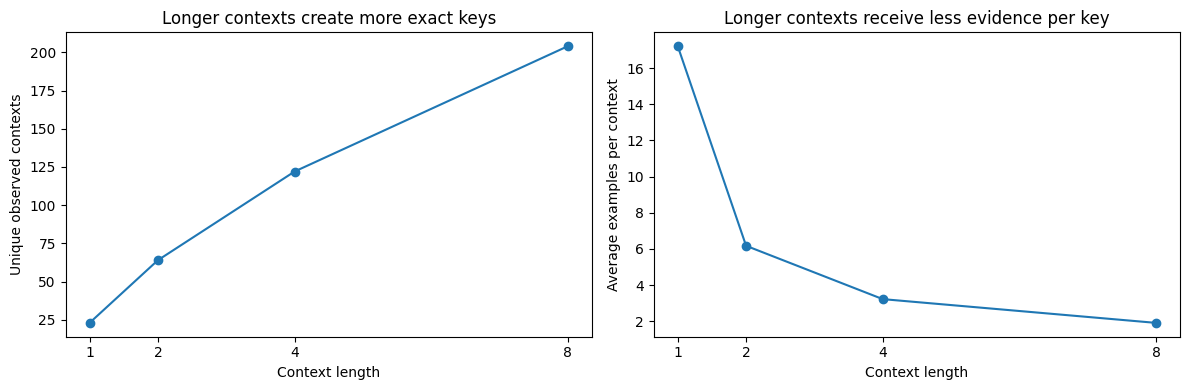

In [12]:
import matplotlib.pyplot as plt  # noqa: I001


unique_context_counts = [row["unique_contexts"] for row in context_summary_rows]
average_examples = [row["average_examples"] for row in context_summary_rows]

figure, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(context_lengths, unique_context_counts, marker="o")
axes[0].set_xlabel("Context length")
axes[0].set_ylabel("Unique observed contexts")
axes[0].set_title("Longer contexts create more exact keys")
axes[0].set_xticks(context_lengths)

axes[1].plot(context_lengths, average_examples, marker="o")
axes[1].set_xlabel("Context length")
axes[1].set_ylabel("Average examples per context")
axes[1].set_title("Longer contexts receive less evidence per key")
axes[1].set_xticks(context_lengths)

plt.tight_layout()
plt.show()

## Smooth Observed Context Rows

Add-alpha smoothing ensures that every known vocabulary target has positive probability within each observed context row.


In [13]:
def assert_valid_probability_distribution(probabilities: list[float]) -> None:
    if not probabilities:
        raise ValueError("A probability distribution cannot be empty.")
    if any(probability < 0 for probability in probabilities):
        raise ValueError("Probabilities cannot be negative.")
    if abs(sum(probabilities) - 1.0) > 1e-12:
        raise ValueError("Probabilities must sum to 1.")


def smooth_target_counts(
    target_counts: Counter[int],
    vocabulary_size: int,
    alpha: float,
) -> list[float]:
    if alpha <= 0:
        raise ValueError("alpha must be greater than 0.")
    denominator = sum(target_counts.values()) + alpha * vocabulary_size
    probabilities = [
        (target_counts[target_id] + alpha) / denominator
        for target_id in range(vocabulary_size)
    ]
    assert_valid_probability_distribution(probabilities)
    return probabilities


def build_context_probabilities(
    context_to_target_counts: dict[Context, Counter[int]],
    vocabulary_size: int,
    alpha: float,
) -> dict[Context, list[float]]:
    return {
        context: smooth_target_counts(target_counts, vocabulary_size, alpha)
        for context, target_counts in context_to_target_counts.items()
    }

## Define a Direct-Fallback N-Gram Model

When an exact context is absent, this chapter falls directly back to a smoothed unigram distribution.

This simple policy keeps comparisons focused on exact-context coverage and differs from Chapter 17's hierarchical trigram-to-bigram backoff.


In [14]:
class NGramCharacterModel:
    def __init__(
        self,
        context_length: int,
        context_probabilities: dict[Context, list[float]],
        fallback_probabilities: list[float],
    ):
        if context_length < 1:
            raise ValueError("context_length must be at least 1.")
        assert_valid_probability_distribution(fallback_probabilities)
        for row in context_probabilities.values():
            assert_valid_probability_distribution(row)
        self.context_length = context_length
        self.context_probabilities = context_probabilities
        self.fallback_probabilities = fallback_probabilities

    def predict_next_token_probabilities(
        self,
        input_token_ids: list[int],
    ) -> tuple[list[float], bool]:
        if len(input_token_ids) < self.context_length:
            return self.fallback_probabilities, False
        context = tuple(input_token_ids[-self.context_length :])
        if context not in self.context_probabilities:
            return self.fallback_probabilities, False
        return self.context_probabilities[context], True

## Train Any Context Length

One training function builds exact context rows and a common smoothed unigram fallback.


In [15]:
def count_token_ids(token_ids: list[int], vocabulary_size: int) -> list[int]:
    counts = [0 for _ in range(vocabulary_size)]
    for token_id in token_ids:
        if not 0 <= token_id < vocabulary_size:
            raise ValueError(f"Invalid token ID {token_id}.")
        counts[token_id] += 1
    return counts


def smooth_count_list(counts: list[int], alpha: float) -> list[float]:
    if not counts:
        raise ValueError("counts cannot be empty.")
    if alpha <= 0:
        raise ValueError("alpha must be greater than 0.")
    denominator = sum(counts) + alpha * len(counts)
    probabilities = [(count + alpha) / denominator for count in counts]
    assert_valid_probability_distribution(probabilities)
    return probabilities


def train_ngram_model(
    training_token_ids: list[int],
    vocabulary_size: int,
    context_length: int,
    alpha: float,
) -> NGramCharacterModel:
    context_counts = build_context_counts(training_token_ids, context_length)
    context_probabilities = build_context_probabilities(
        context_counts,
        vocabulary_size,
        alpha,
    )
    fallback_probabilities = smooth_count_list(
        count_token_ids(training_token_ids, vocabulary_size),
        alpha,
    )
    return NGramCharacterModel(
        context_length,
        context_probabilities,
        fallback_probabilities,
    )


ALPHA = 0.1
models_by_context_length = {
    context_length: train_ngram_model(
        training_token_ids,
        len(character_vocabulary),
        context_length,
        ALPHA,
    )
    for context_length in context_lengths
}

print("Trained context lengths:", list(models_by_context_length))

Trained context lengths: [1, 2, 4, 8]


## Build Held-Out Context-Target Examples

Validation examples are created only from validation tokens and are never added to the fitted counts.


In [16]:
def build_context_target_examples(
    token_ids: list[int],
    context_length: int,
) -> tuple[list[list[int]], list[int]]:
    if context_length < 1:
        raise ValueError("context_length must be at least 1.")
    if context_length >= len(token_ids):
        raise ValueError("context_length must be smaller than the token sequence.")

    contexts = []
    targets = []
    for start_position in range(len(token_ids) - context_length):
        contexts.append(token_ids[start_position : start_position + context_length])
        targets.append(token_ids[start_position + context_length])
    return contexts, targets


example_contexts, example_targets = build_context_target_examples(
    validation_token_ids,
    context_length=4,
)

for example_number in range(8):
    print(
        f"example {example_number}: "
        f"{decode_character_ids(example_contexts[example_number], id_to_character)!r} "
        f"→ {id_to_character[example_targets[example_number]]!r}"
    )

example 0: 'the ' → 's'
example 1: 'he s' → 'm'
example 2: 'e sm' → 'a'
example 3: ' sma' → 'l'
example 4: 'smal' → 'l'
example 5: 'mall' → ' '
example 6: 'all ' → 'c'
example 7: 'll c' → 'a'


## Compute Average Validation Negative Log Loss

For target probability $p$, the example loss is $-\log(p)$.

High target probability produces low loss, and lower average validation loss is better.

Chapter 19 will examine log probabilities and this loss more deeply.


In [17]:
import math  # noqa: I001


def evaluate_model(
    model: NGramCharacterModel,
    validation_token_ids: list[int],
) -> tuple[float, float]:
    context_examples, target_examples = build_context_target_examples(
        validation_token_ids,
        model.context_length,
    )
    losses = []
    unseen_count = 0

    for context_ids, target_id in zip(
        context_examples,
        target_examples,
        strict=True,
    ):
        probabilities, exact_context_observed = model.predict_next_token_probabilities(
            context_ids
        )
        if not exact_context_observed:
            unseen_count += 1
        target_probability = probabilities[target_id]
        if target_probability <= 0:
            raise ValueError("Smoothing should keep target probability positive.")
        losses.append(-math.log(target_probability))

    return sum(losses) / len(losses), unseen_count / len(losses)

## Compare All Context Lengths

The table joins fit statistics with held-out loss and exact-context coverage.


In [18]:
evaluation_rows = []

for context_length in context_lengths:
    model = models_by_context_length[context_length]
    validation_loss, unseen_fraction = evaluate_model(
        model,
        validation_token_ids,
    )
    summary = next(
        row for row in context_summary_rows if row["context_length"] == context_length
    )
    evaluation_rows.append(
        {
            **summary,
            "validation_loss": validation_loss,
            "unseen_fraction": unseen_fraction,
        }
    )

print("Context | N-gram | Unique | Avg examples | Validation loss | Unseen fraction")
print("-" * 82)
for row in evaluation_rows:
    print(
        f"{row['context_length']:>7} | {row['ngram_size']:>6} | "
        f"{row['unique_contexts']:>6} | {row['average_examples']:>12.3f} | "
        f"{row['validation_loss']:>15.6f} | {row['unseen_fraction']:>15.3f}"
    )

Context | N-gram | Unique | Avg examples | Validation loss | Unseen fraction
----------------------------------------------------------------------------------
      1 |      2 |     23 |       17.217 |        1.611978 |           0.000
      2 |      3 |     64 |        6.172 |        1.215721 |           0.099
      4 |      5 |    122 |        3.221 |        1.431613 |           0.192
      8 |      9 |    204 |        1.907 |        1.914819 |           0.407


## Plot Held-Out Results

Validation loss measures prediction quality, while unseen fraction explains how often the direct unigram fallback replaced an exact context row.


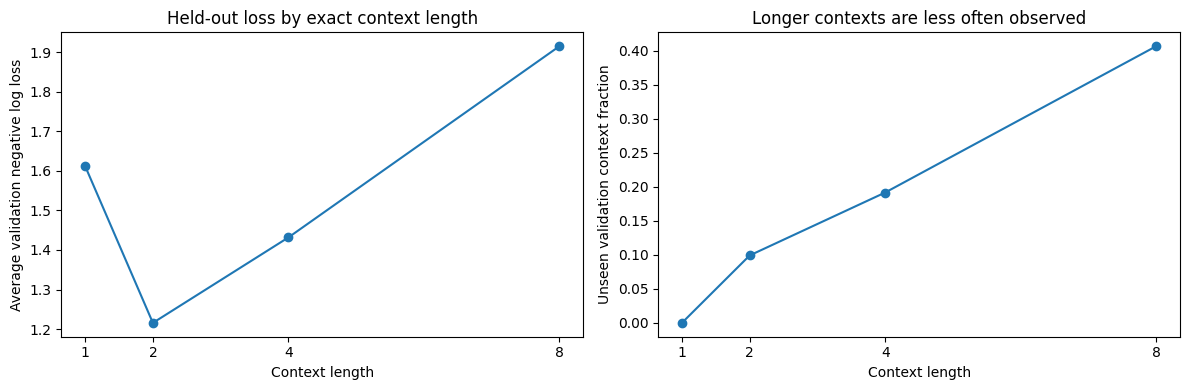

In [19]:
validation_losses = [row["validation_loss"] for row in evaluation_rows]
unseen_fractions = [row["unseen_fraction"] for row in evaluation_rows]

figure, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(context_lengths, validation_losses, marker="o")
axes[0].set_xlabel("Context length")
axes[0].set_ylabel("Average validation negative log loss")
axes[0].set_title("Held-out loss by exact context length")
axes[0].set_xticks(context_lengths)

axes[1].plot(context_lengths, unseen_fractions, marker="o")
axes[1].set_xlabel("Context length")
axes[1].set_ylabel("Unseen validation context fraction")
axes[1].set_title("Longer contexts are less often observed")
axes[1].set_xticks(context_lengths)

plt.tight_layout()
plt.show()

## Interpret This Fixture's Actual Result

The next cell identifies the best measured context length and checks whether unseen validation contexts increase overall.

These findings belong to this split, smoothing value, and fallback policy rather than being universal laws.


In [20]:
best_row = min(evaluation_rows, key=lambda row: row["validation_loss"])
unseen_fraction_increased = unseen_fractions[-1] > unseen_fractions[0]

print("Lowest-loss context length:", best_row["context_length"])
print("Lowest validation loss:", best_row["validation_loss"])
print("Unseen fraction increased from length 1 to 8:", unseen_fraction_increased)

Lowest-loss context length: 2
Lowest validation loss: 1.2157213234952775
Unseen fraction increased from length 1 to 8: True


Longer exact context can help when a matching pattern is available, but missing matches force this model all the way back to context-free unigram probabilities.

Changing the corpus, alpha, split, or backoff policy can change which context length performs best.


## Generate From Every Model

Generation is useful for intuition, while validation loss provides the more systematic comparison.


In [21]:
import random  # noqa: I001


RANDOM_SEED = 18


def sample_token_id(
    probabilities: list[float],
    random_generator: random.Random,
) -> int:
    assert_valid_probability_distribution(probabilities)
    return random_generator.choices(
        range(len(probabilities)),
        weights=probabilities,
        k=1,
    )[0]


def generate_text(
    model: NGramCharacterModel,
    prompt: str,
    number_of_new_characters: int,
    character_to_id: dict[str, int],
    id_to_character: dict[int, str],
    random_seed: int,
) -> tuple[str, int]:
    if number_of_new_characters < 0:
        raise ValueError("number_of_new_characters cannot be negative.")

    random_generator = random.Random(random_seed)
    generated_text = prompt
    fallback_count = 0
    for _ in range(number_of_new_characters):
        input_ids = encode_characters(generated_text, character_to_id)
        probabilities, exact_context_observed = model.predict_next_token_probabilities(
            input_ids
        )
        if not exact_context_observed:
            fallback_count += 1
        next_id = sample_token_id(probabilities, random_generator)
        generated_text += id_to_character[next_id]
    return generated_text, fallback_count


for context_length in context_lengths:
    generated_text, fallback_count = generate_text(
        models_by_context_length[context_length],
        prompt="the ",
        number_of_new_characters=120,
        character_to_id=character_to_id,
        id_to_character=id_to_character,
        random_seed=RANDOM_SEED,
    )
    print("Context length:", context_length)
    print("Fallback steps:", fallback_count)
    print(generated_text)
    print()

Context length: 1
Fallback steps: 0
the che on og satheog the the at sathe fd.g se che odhe irug can rathedcat sled mathe t.
yacbe the rd the rd. t chipk the ya

Context length: 2
Fallback steps: 55
the chihe fom.matemt.
the the .t rmhfsha et ruf lmde rrgbrsg ai in the rlu lseo eadn tia ya
h  on the the matepd srna snooue

Context length: 4
Fallback steps: 116
the chiheeee..malptt..nh lts a
t nghfsha et lh  lede nhgbrsg    ig thrrlfu lter eadn bsa yg
h  oieehe ooedheett  ptna stoote

Context length: 8
Fallback steps: 120
the  ib eeee..malptt..nh lts a
t nghfsha et lh  lede nhgbrsg    ig thrrlfu lter eadn bsa yg
h  oieehe ooedheett  ptna stoote



Longer models can reproduce longer training-like fragments when an exact context is found, but their samples can also expose frequent fallback after a novel transition.


## Trace a 5-Gram Model

The trace shows the exact four-character context and whether that key was observed during training.


In [22]:
def trace_generation(
    model: NGramCharacterModel,
    prompt: str,
    number_of_new_characters: int,
    character_to_id: dict[str, int],
    id_to_character: dict[int, str],
    random_seed: int,
) -> str:
    random_generator = random.Random(random_seed)
    generated_text = prompt

    for step in range(number_of_new_characters):
        input_ids = encode_characters(generated_text, character_to_id)
        probabilities, observed = model.predict_next_token_probabilities(input_ids)
        context_text = generated_text[-model.context_length :]
        next_id = sample_token_id(probabilities, random_generator)
        print(
            f"step {step + 1:>2}: context {context_text!r:>10}, "
            f"observed {str(observed):<5}, sampled {id_to_character[next_id]!r}"
        )
        generated_text += id_to_character[next_id]
    return generated_text


traced_text = trace_generation(
    models_by_context_length[4],
    prompt="the ",
    number_of_new_characters=12,
    character_to_id=character_to_id,
    id_to_character=id_to_character,
    random_seed=RANDOM_SEED,
)
print("Final traced text:", repr(traced_text))

step  1: context     'the ', observed True , sampled 'c'
step  2: context     'he c', observed True , sampled 'h'
step  3: context     'e ch', observed True , sampled 'i'
step  4: context     ' chi', observed True , sampled 'h'
step  5: context     'chih', observed False, sampled 'e'
step  6: context     'hihe', observed False, sampled 'e'
step  7: context     'ihee', observed False, sampled 'e'
step  8: context     'heee', observed False, sampled 'e'
step  9: context     'eeee', observed False, sampled '.'
step 10: context     'eee.', observed False, sampled '.'
step 11: context     'ee..', observed False, sampled 'm'
step 12: context     'e..m', observed False, sampled 'a'
Final traced text: 'the chiheeee..ma'


## Compare Possible Context Space

The possible exact context count $V^C$ grows far faster than the number of training examples.


Context length | Possible contexts | Observed contexts
----------------------------------------------------------
             1 |                23 |                23
             2 |               529 |                64
             4 |            279841 |               122
             8 |       78310985281 |               204


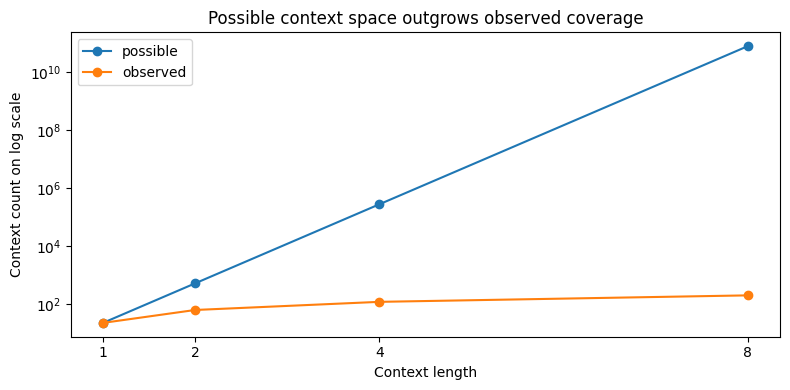

In [23]:
possible_context_counts = [
    len(character_vocabulary) ** context_length for context_length in context_lengths
]

print("Context length | Possible contexts | Observed contexts")
print("-" * 58)
for context_length, possible_count, observed_count in zip(
    context_lengths,
    possible_context_counts,
    unique_context_counts,
    strict=True,
):
    print(f"{context_length:>14} | {possible_count:>17} | {observed_count:>17}")

plt.figure(figsize=(8, 4))
plt.semilogy(context_lengths, possible_context_counts, marker="o", label="possible")
plt.semilogy(context_lengths, unique_context_counts, marker="o", label="observed")
plt.xlabel("Context length")
plt.ylabel("Context count on log scale")
plt.title("Possible context space outgrows observed coverage")
plt.xticks(context_lengths)
plt.legend()
plt.tight_layout()
plt.show()

The logarithmic vertical scale is necessary because the possible counts span many orders of magnitude.


## Exact Counting Cannot Share Similarity

Contexts such as `"the cat "`, `"the dog "`, and `"the bird"` share visible structure to a reader.

An exact n-gram dictionary treats them as unrelated tuple keys unless their exact tokens match.

Later neural models will learn vector representations that can share statistical strength across related contexts instead of relying only on exact lookup.


## Complete General N-Gram Pipeline

The final cell rebuilds all models and verifies that every evaluation result is finite and every context count matches $N-C$.


In [24]:
final_rows = []

for context_length in context_lengths:
    final_counts = build_context_counts(training_token_ids, context_length)
    assert total_context_target_count(final_counts) == (
        len(training_token_ids) - context_length
    )
    final_model = train_ngram_model(
        training_token_ids,
        len(character_vocabulary),
        context_length,
        ALPHA,
    )
    final_loss, final_unseen_fraction = evaluate_model(
        final_model,
        validation_token_ids,
    )
    assert math.isfinite(final_loss)
    final_rows.append((context_length, final_loss, final_unseen_fraction))

print("Context | Validation loss | Unseen fraction")
print("-" * 48)
for context_length, validation_loss, unseen_fraction in final_rows:
    print(f"{context_length:>7} | {validation_loss:>15.6f} | {unseen_fraction:>15.3f}")

Context | Validation loss | Unseen fraction
------------------------------------------------
      1 |        1.611978 |           0.000
      2 |        1.215721 |           0.099
      4 |        1.431613 |           0.192
      8 |        1.914819 |           0.407


## Common Mistakes

- Keep n-gram size equal to context length plus one.

- Use an ordered tuple for each exact context.

- Place the target immediately after the context slice.

- Expect $N-C$ examples from a sequence of length $N$ and context length $C$.

- Do not infer model quality from the number of unique contexts alone.

- Report unseen validation contexts because fallback policy affects validation loss.

- Use held-out loss rather than generated appearance alone when comparing context lengths.


## Takeaways

One `build_context_counts` function can fit exact count models for any positive context length.

Longer contexts provide more specific information but create up to $V^C$ possible tuple keys and reduce the evidence per observed key.

Validation loss and unseen-context fraction reveal whether that added specificity helps on held-out text under the chosen smoothing and fallback policy.

Exact n-gram counting cannot naturally share evidence among similar but nonidentical contexts.

The next chapter examines log probabilities in detail, including why products of many small probabilities become sums and how average negative log probability supports stable model evaluation.
